# 📊 Préparation des données - Projet MLOps

## 🎯 Objectif
L'objectif de cette étape est de préparer les données pour la phase de modélisation en appliquant :
- Nettoyage des données
- Encodage des variables
- Séparation Train/Test

## 1. Installation et Importation des outils.
Dans cette section, nous import les library necessaires:
* **Pandas** : Pour la manipulation des donnees tabulaires.
* **Seaborn/Matplotlib** : Pour la visualisation graphique.
* **Scikit-Learn** : Pour le pretraitement et la separation des donnees.

In [1]:
#Import des bibliothèques
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sea
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
import os


In [18]:
os.chdir(r"D:\pfe-mlops-scolaire")

# 2. Chargement des donnees.
Nous utilisons le jeu de données **"student-mat-before.csv"** provenant de l'UCI. Les données sont séparées par des points-virgules (`;`).

In [21]:
#chargement avec le bon separateur
data = pd.read_csv('data/student-mat-before.csv', sep=';')

## 4. Nettoyage et Intégrité
Cette étape consiste à vérifier s'il existe des **valeurs manquantes** ou des **doublons** qui pourraient fausser les résultats de l'apprentissage automatique.

Valeurs manquantes par colonnes :
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Nombre de lignes en double : 0


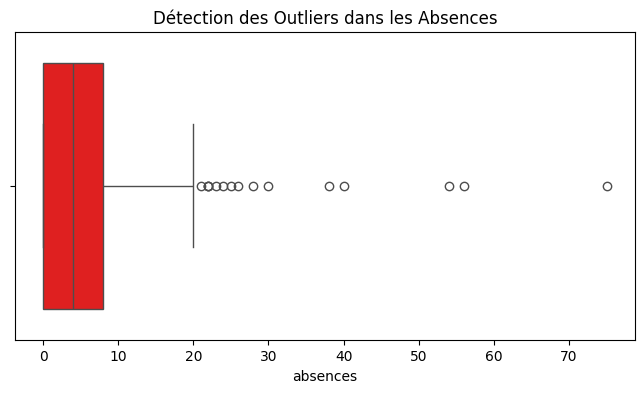

In [3]:
#1. vérification des valeurs manquantes
print("Valeurs manquantes par colonnes :")
print(data.isnull().sum())

#2.Vérificationes et suppression des doublons 
dubl = data.duplicated()
dubl_count = dubl.sum()
print(f"\nNombre de lignes en double : {dubl_count}")

#3.Analyse des Outliers
plt.figure(figsize=(8, 4))
sea.boxplot(x=data['absences'], color='red')
plt.title('Détection des Outliers dans les Absences')
plt.show()

# 5.Sélectionner et supprimer les colonnes non importantes
Ces colonnes sont supprimées car elles n'ont pas d'impact direct sur la prédiction des résultats scolaires.

In [4]:
#Liste des colonnes considérées comme inutiles (n'ajoutent aucune valeur à notre projet)
drop_cols = ['school', 'reason', 'address']
#Suppression des colonnes 
data_reduced = data.drop(columns=drop_cols)
print(f"Ancien nombre de colonnes : {data.shape[1]}")
print(f"Neouveau nombre de colonnes : {data_reduced.shape[1]}")

Ancien nombre de colonnes : 33
Neouveau nombre de colonnes : 30


# 6 --> 1 :Codage des variables catégorielles

In [5]:
 #1.Tableau des colonnes à deux options ---> codage-ordinal
binary_cols = ['sex', 'famsize', 'Pstatus', 'schoolsup', 'famsup', 'paid',
               'activities', 'nursery', 'higher', 'internet', 'romantic']

# Application de {OrdinalEncoder}
ordinal_encod= OrdinalEncoder()
data_reduced[binary_cols] = ordinal_encod.fit_transform(data_reduced[binary_cols])

In [6]:
#2.Détection des variables nominales (> 2 catégories) ---> OneHotEncoder
nominal_cols = ['Mjob', 'Fjob', 'guardian']

# Application de {OneHotEncoder}
onehot_encod = OneHotEncoder(sparse_output=False, drop='first')
nominal_encod = onehot_encod.fit_transform(data_reduced[nominal_cols])

# Remarque:
**Reconstruction du DataFrame après Encodage Nominal**
Après avoir appliqué le **OneHotEncoder** sur les variables nominales, nous convertissons la matrice résultante en un **DataFrame** structuré. 
* **Colonnes** : Nous utilisons `get_feature_names_out` pour nommer chaque colonne selon la modalité de la variable d'origine (ex: `sex_F`, `sex_M`).
* **Index** : Nous conservons l'index d'origine pour garantir la cohérence lors de la fusion future des données.

In [7]:
#Créez un dataframe avec de nouveaux noms
nominla_datafarme= pd.DataFrame(nominal_encod,columns=onehot_encod.get_feature_names_out(nominal_cols),index=data_reduced.index)

print(nominla_datafarme.shape[1])

10


# 6 --> 2 : Sauvegarde du dataset nettoyé.

In [11]:
#Fusion avec la dataset principale et supp des colonnes text 
final_data = pd.concat([data_reduced.drop(columns=nominal_cols), nominla_datafarme], axis=1)
print(final_data.head())
final_data.to_csv(r'D:\pfe-mlops-scolaire\data\student-cleaned.csv', index=False)
print("Le fichier student-cleaned.csv enregistre avec succes !")

   sex  age  famsize  Pstatus  Medu  Fedu  traveltime  studytime  failures  \
0  0.0   18      0.0      0.0     4     4           2          2         0   
1  0.0   17      0.0      1.0     1     1           1          2         0   
2  0.0   15      1.0      1.0     1     1           1          2         3   
3  0.0   15      0.0      1.0     4     2           1          3         0   
4  0.0   16      0.0      1.0     3     3           1          2         0   

   schoolsup  ...  Mjob_health  Mjob_other  Mjob_services  Mjob_teacher  \
0        1.0  ...          0.0         0.0            0.0           0.0   
1        0.0  ...          0.0         0.0            0.0           0.0   
2        1.0  ...          0.0         0.0            0.0           0.0   
3        0.0  ...          1.0         0.0            0.0           0.0   
4        0.0  ...          0.0         1.0            0.0           0.0   

   Fjob_health  Fjob_other  Fjob_services  Fjob_teacher  guardian_mother  \
0   

# 6 --> 3 : Séparation du dataset en ensembles d'entraînement (Train) et de test (Test).

In [20]:

# Separation des donnees Features/Target
X = final_data.drop('G3', axis=1)
Y = final_data['G3']
#Split train/ test
X_train,X_test,Y_train,Y_test = train_test_split(X,Y, test_size=0.2,random_state=42)
#Afficher dimension
print("X_train: ",X_train.shape)
print("X_test: ",X_test.shape)
print("y_train: ",Y_train.shape)
print("y_test: ",Y_test.shape)
X_train.to_csv("data/X_train.csv", index=False)
X_test.to_csv("data/X_test.csv", index=False)
Y_train.to_csv("data/y_train.csv", index=False)
Y_test.to_csv("data/y_test.csv", index=False)

X_train:  (316, 36)
X_test:  (79, 36)
y_train:  (316,)
y_test:  (79,)


# 7.la visualisation des données:


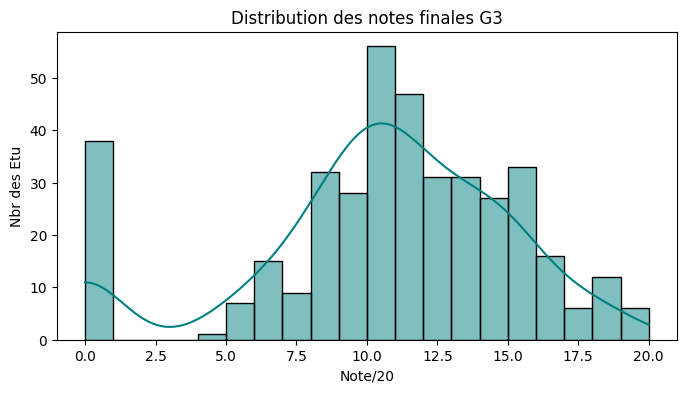

In [ ]:

# 1. Distribution de la note finale [G3]
plt.figure(figsize=(8, 4))
sea.histplot(final_data['G3'], bins=20, kde=True, color='teal')
plt.title('Distribution des notes finales G3')
plt.xlabel('Note/20')
plt.ylabel('Nbr des Etu')
plt.show()

La **matrice de corrélation** est un outil statistique essentiel pour comprendre les relations linéaires entre nos variables numériques. 

* **Objectif** : Identifier quelles variables (ex: absences, temps d'étude, notes passées G1/G2) ont la plus forte influence sur la note finale **G3**.
* **Interprétation** : 
    * Une valeur proche de **1** indique une corrélation positive forte.
    * Une valeur proche de **-1** indique une corrélation négative forte.
    * Une valeur proche de **0** indique l'absence de relation linéaire.

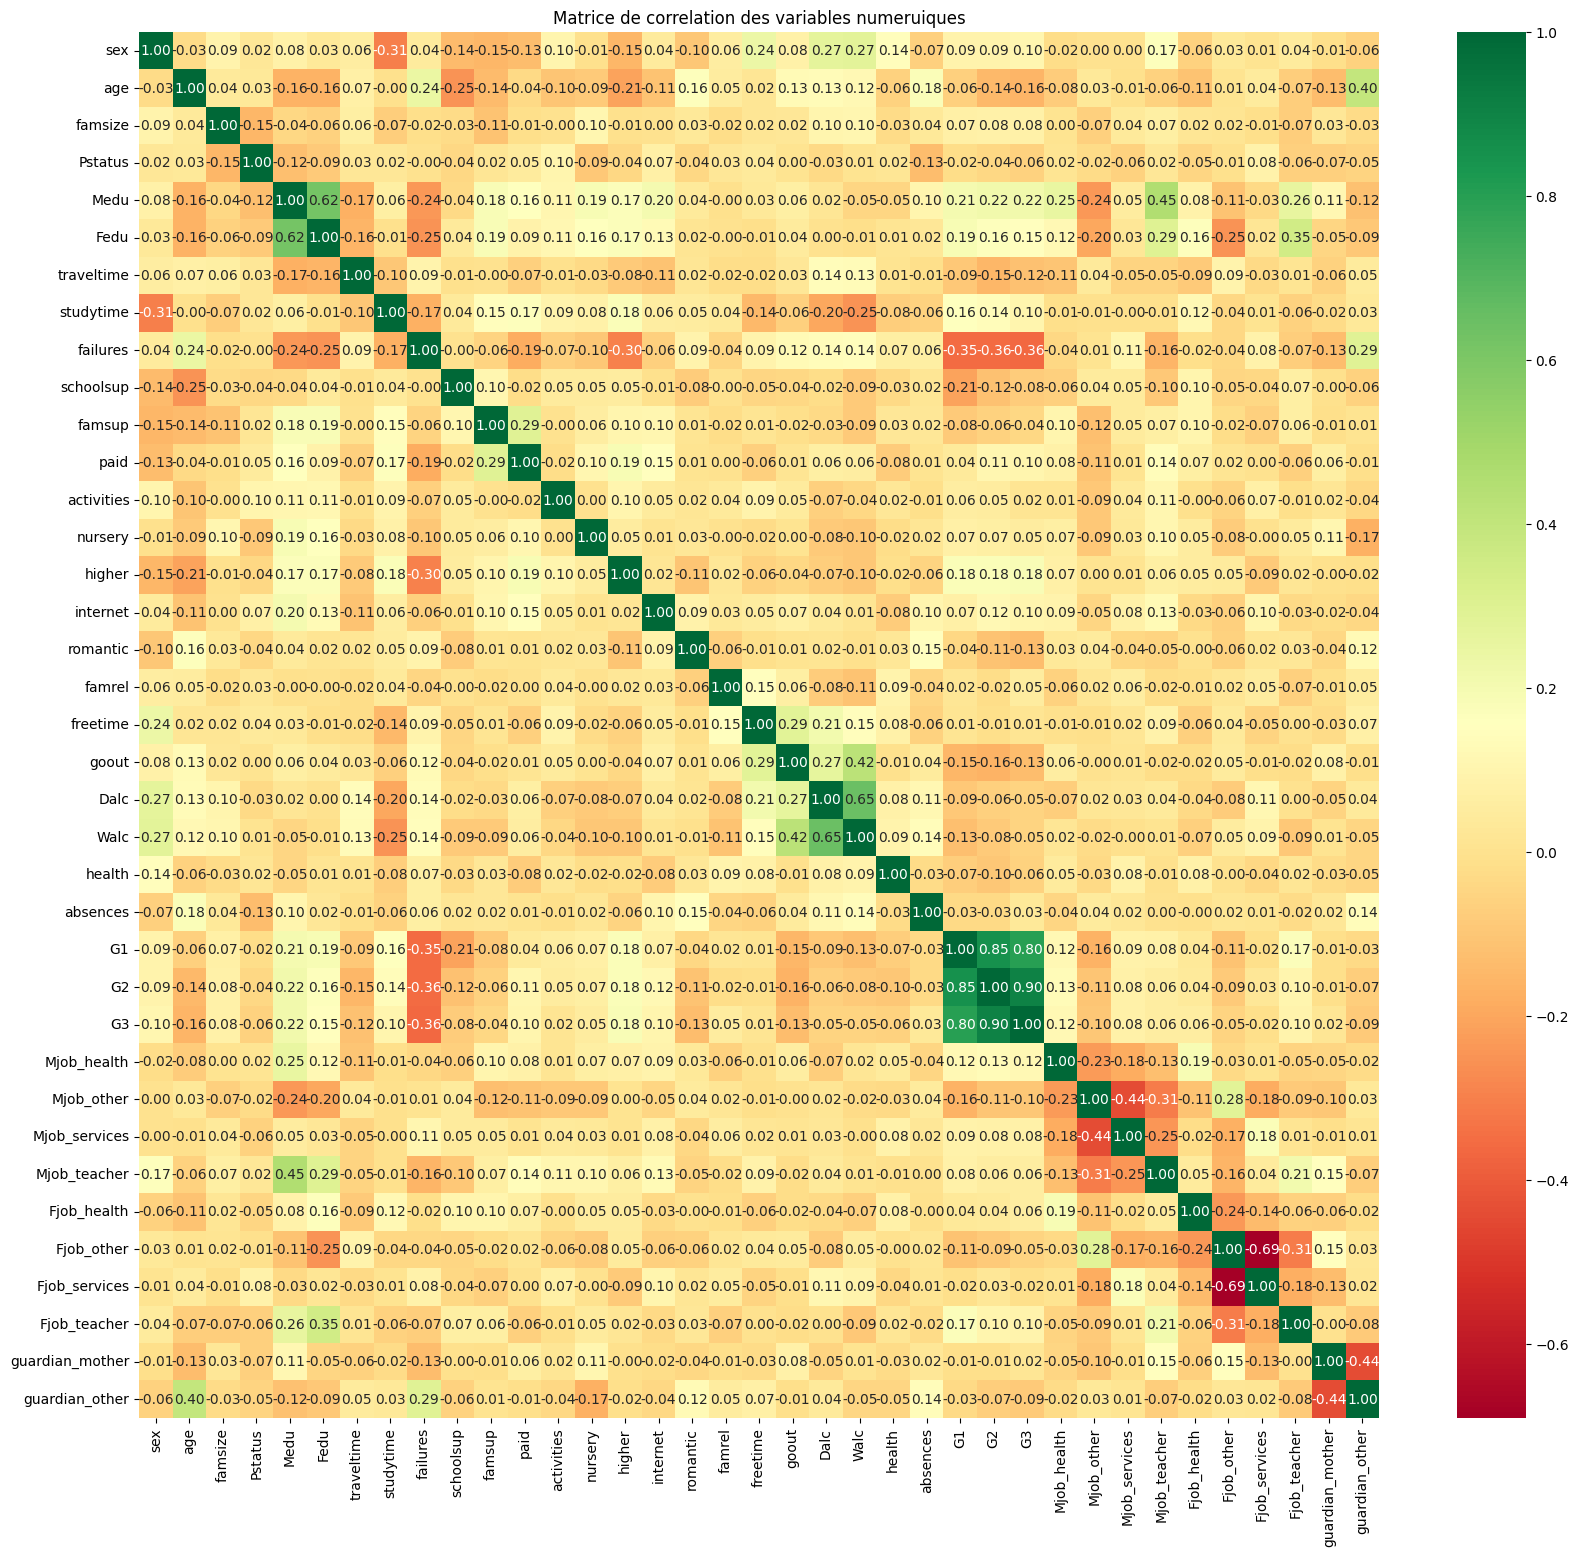

In [58]:
# 2. matrice de corrélation
#select only les colonnes numerique
num_cl_of_data = final_data.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(20, 18))
sea.heatmap(num_cl_of_data.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Matrice de correlation des variables numeruiques')
plt.show()

Cette visualisation examine la corrélation entre le **temps d'étude hebdomadaire** (`studytime`) et la **note finale** (`G3`).

* **Variables** : Le temps d'étude est catégorisé de **1** (moins de 2h) à **4** (plus de 10h).
* **Objectif** : Vérifier si une augmentation du temps de travail se traduit par une hausse significative de la note moyenne ou par une réduction de l'échec scolaire (notes proches de 0).

C:\Users\pc HD\AppData\Local\Temp\ipykernel_1600\2874701607.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sea.scatterplot(x=final_data['studytime'], y=final_data['G3'], palette='Set3')


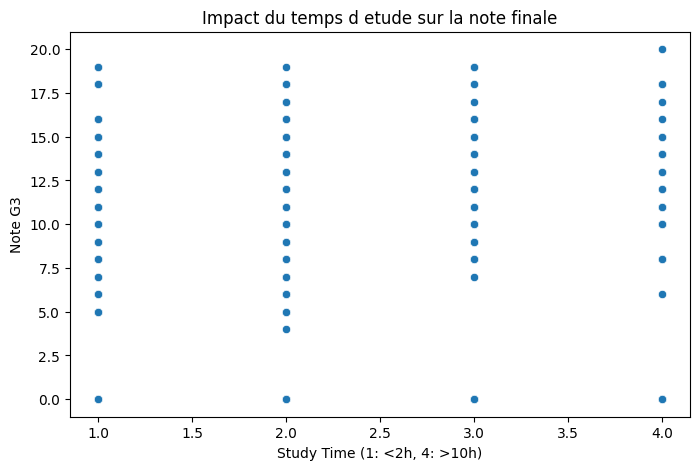

In [50]:
# 3. La relation entre StudyTime Vs G3
plt.figure(figsize=(8, 5))
sea.scatterplot(x=final_data['studytime'], y=final_data['G3'], palette='Set3')
plt.title('Impact du temps d etude sur la note finale')
plt.xlabel('Study Time (1: <2h, 4: >10h)')
plt.ylabel('Note G3')
plt.show()

Nous analysons ici si un nombre élevé d'**absences** a un impact direct sur la baisse de la note finale (**G3**). 

* **Hypothèse** : Un absentéisme important nuit à l'assimilation des cours et devrait, en théorie, se traduire par des notes plus faibles.
* **Méthode** : Le nuage de points permet de voir s'il existe un seuil critique d'absences à partir duquel la réussite devient impossible.

C:\Users\pc HD\AppData\Local\Temp\ipykernel_1600\153754366.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sea.scatterplot(x='absences', y='G3', data=final_data, palette='Set6')


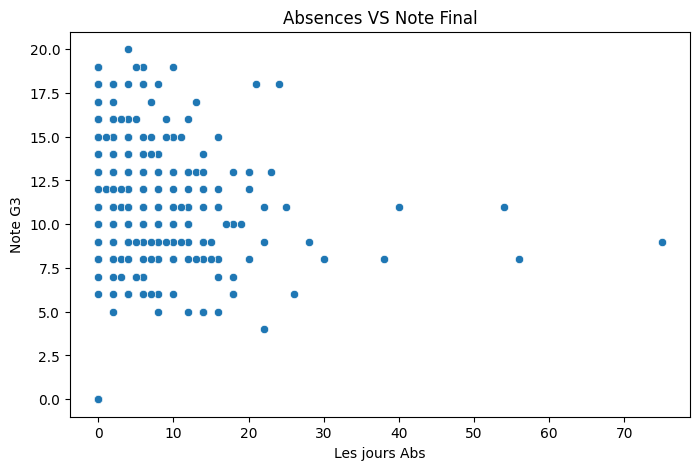

In [51]:
# 4.Relation entre Absences VS G3
plt.figure(figsize=(8, 5))
sea.scatterplot(x='absences', y='G3', data=final_data, palette='Set6')
plt.title('Absences VS Note Final')
plt.xlabel('Les jours Abs')
plt.ylabel('Note G3')
plt.show()

## ✅ Conclusion

Les données ont été :
- Nettoyées
- Encodées 
- visualisées
- Séparées en ensembles d'entraînement et de test

Elles sont maintenant prêtes pour la phase de modélisation.

In [14]:
print(os.getcwd())

d:\pfe-mlops-scolaire\notebooks
